In [1]:
# Rotina 1 - Instalação e importação de bibliotecas
!pip install lightkurve --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import lightkurve as lk
from lightkurve import LightCurve
from astropy.timeseries import BoxLeastSquares
from astropy import units as u
from astropy.constants import G, M_sun, R_sun

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 64.0 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=100bec2978e789d89b41b02fd88d851304d7406d77d97eee6c68a61fe23b9576
  Stored in directory: /root/.cache/pip/wheels/30/85/d4/289ba063a9ae0ba3189c6914e992722575868b2cb41100401b
  Created wheel for memoization

/usr/local/lib/python3.13/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# Rotina 2 - Obtendo os dados da estrela do TESS
TIC_ID = "38965512"
available_data_all = lk.search_lightcurve(f"TIC{ TIC_ID}", author = 'SPOC')
available_data_all

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 68,2023,SPOC,120,38965512,0.0
1,TESS Sector 69,2023,SPOC,120,38965512,0.0
2,TESS Sector 95,2025,SPOC,120,38965512,0.0
3,TESS Sector 96,2025,SPOC,120,38965512,0.0
4,TESS Sector 103,2026,SPOC,120,38965512,0.0


Total de dados faltantes da variável Flux:  ———
Total percentual de dados faltantes: 11.92%


<Figure size 1000x500 with 0 Axes>

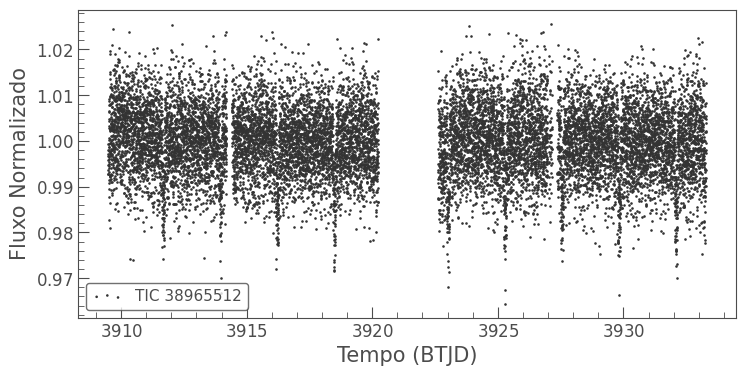

In [4]:
# Rotina 3 Plotar Grafico
# Baixando e verificando os dados
search_result = lk.search_lightcurve(f"TIC {TIC_ID}", author="SPOC", sector=96)  # Setor(sector) selecionado: 96. Subistituir pelo da estrela analisada
lc_collection = search_result.download_all()
lc = lc_collection.stitch().normalize()

# Tratamento dos dados
nans_flux = np.isnan(lc.flux.value).sum()
nans_percent = round(float(nans_flux * 100) / len(lc.flux.value), 2)

print(f"Total de dados faltantes da variável Flux: {nans_flux}")
print(f"Total percentual de dados faltantes: {nans_percent}%")

# Removendo valores nulos e outliers
lc = lc.remove_nans()
mean = np.mean(lc.flux.value)
sigma = np.std(lc.flux.value)

lc = lc[(lc.flux.value > mean - 5*sigma) &
        (lc.flux.value < mean + 5*sigma)]

# Plotando a curva de luz tratada
plt.figure(figsize=(10,5))
lc.scatter(s=3)
plt.xlabel("Tempo (BTJD)")
plt.ylabel("Fluxo Normalizado")
plt.title(f"")
# SALVAR A FIGURA
plt.savefig(f"curva_luz_tratada_TIC_{TIC_ID}.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Período BLS: 2.26930 dias
Profundidade: 1.19670e-02
Duração: 0.1130 dias


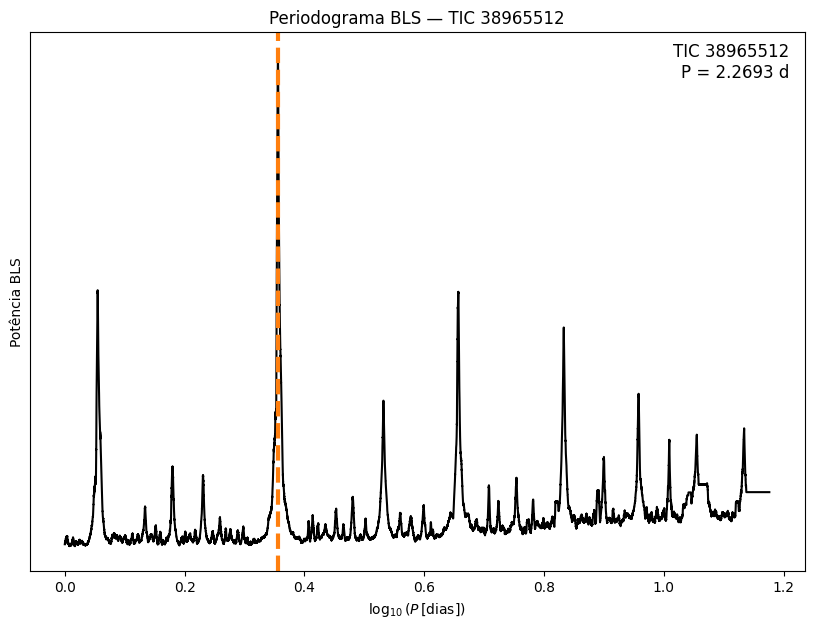

In [5]:
# Rotina 4 - Estimando o Período com BLS

# Definir tempo e fluxo
lc = lc . normalize ()

x = lc.time.value         # tempo em dias
y = lc . flux . value     # fluxo normalizado

# ---------- Configuração da grade de períodos ----------
# Faixa de períodos a testar (em dias)
period_min = 1.0          # Mínimo: 1 dia (órbitas ultra-curtas)
period_max = 15.0         # Máximo: 15 dias (limite prático para TESS em setor único)
n_periods = 50000         # Número de pontos na grade logarítmica (balanço resolução x tempo)

# Cria grade logarítmica (melhor para detectar planetas com períodos variando em ordens de grandeza)
period_grid = np.logspace(np.log10(period_min), np.log10(period_max), n_periods)

# ---------- Configuração das durações de trânsito ----------
dur_min = 0.02            # Duração mínima (dias) - ~28 minutos, típica de Júpiteres quentes
dur_max = 0.3             # Duração máxima (dias) - ~7 horas, para órbitas de poucos dias
n_durations = 10          # Quantas durações testar

durations = np.linspace(dur_min, dur_max, n_durations)

# ---------- Instanciar BLS ----------
bls = BoxLeastSquares(x, y)

# ---------- Cálculo do periodograma ----------
bls_power = bls.power(
    period_grid,
    durations,
    oversample=20
)
# ---------- Melhor solução ----------
index = np.argmax(bls_power.power)

bls_period = bls_power.period[index]
bls_t0 = bls_power.transit_time[index]
bls_depth = bls_power.depth[index]
bls_duration = bls_power.duration[index]

print(f"Período BLS: {bls_period:.5f} dias")
print(f"Profundidade: {bls_depth:.5e}")
print(f"Duração: {bls_duration:.4f} dias")

# ---------- Plot do periodograma ----------
plt.figure(figsize=(10,7))

plt.plot(
    np.log10(bls_power.period),
    bls_power.power,
    color="black"
)

plt.axvline(
    np.log10(bls_period),
    color="C1",
    lw=3,
    ls="--"
)

plt.text(
    0.98, 0.98,
    f"TIC {TIC_ID}\nP = {bls_period:.4f} d",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12
)

plt.xlabel(r"$\log_{10}(P\,[\mathrm{dias}])$")
plt.ylabel("Potência BLS")
plt.title(f"Periodograma BLS — TIC {TIC_ID}")
plt.yticks([])

plt.savefig(
    f"periodograma_BLS_TIC_{TIC_ID}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



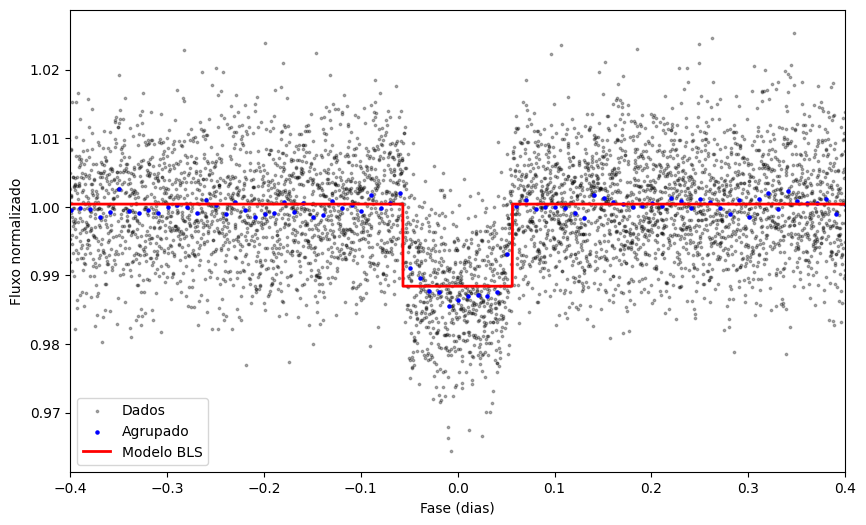

In [9]:
# Rotina 5 - Curva de Luz Dobrada
# Converter para LightCurve
lc_fold = lc.fold(
    period=bls_period,
    epoch_time=bls_t0
).normalize()

# Modelo BLS no tempo original
model_flux = bls.model(
    lc.time.value,
    bls_period,
    bls_duration,
    bls_t0
)

model_lc = LightCurve(
    time=lc.time,
    flux=model_flux
)

# Dobrar modelo
model_lc_fold = model_lc.fold(
    period=bls_period,
    epoch_time=bls_t0
)

bls_duration_adj = 1.3 * bls_duration

model_flux = bls.model(
    lc.time.value,
    bls_period,
    bls_duration_adj,
    bls_t0
)

lc_bin = lc_fold.bin(time_bin_size=0.01)

plt.figure(figsize=(10,6))

# Dados brutos
plt.scatter(
    lc_fold.time.value,
    lc_fold.flux.value,
    s=3, alpha=0.3, color="black", label="Dados"
)

# Dados binned
plt.scatter(
    lc_bin.time.value,
    lc_bin.flux.value,
    s=5, color="blue", label="Agrupado"
)

# Modelo BLS
plt.plot(
    model_lc_fold.time.value,
    model_lc_fold.flux.value,
    color="red", lw=2, label="Modelo BLS"
)

plt.xlim(-0.4, 0.4) # Delimitacao do eixo X para ampliacao da curva de luz dobrada - retirar quando reproduzir
plt.xlabel("Fase (dias)")
plt.ylabel("Fluxo normalizado")
plt.title(f"")
plt.legend()

plt.savefig(
    f"curva_de_luz_dobrada_306362738.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [12]:
# Rotina 6 - Estimando o Raio e Semi-eixo maior do exoplaneta

# ---------- Raio do planeta ----------
bls_depth = bls_power.depth[index]  # profundidade (fração de fluxo)

R_star = 1.0785 * R_sun               # (Raio da Estrela em relacao ao raio do Sol. Subistituir pelo raio da estrela analisada.)
R_p = np.sqrt(bls_depth) * R_star    # raio planetário

R_p_earth = R_p.to(u.R_earth)
R_p_jup = R_p.to(u.R_jup)

# ---------- Período orbital ----------
P = bls_power.period[index] * u.day

# ---------- Semi-eixo maior ----------
M_star = 1.01 * M_sun                # (Massa da Estrela em relacao a massa do Sol. Subistituir pela massa da estrela analisada.)

a = ((G * M_star * P**2) / (4 * np.pi**2))**(1/3)
a_AU = a.to(u.AU)

# ---------- Saída ----------
dados = f"""
CANDIDATO A EXOPLANETA — TIC {TIC_ID}

Período orbital (P): {P.value:.4f} {P.unit}
Raio do planeta: {R_p_jup.value:.3f} {R_p_jup.unit}
                 ({R_p_earth.value:.2f} {R_p_earth.unit})
Semi-eixo maior (a): {a_AU.value:.4f} {a_AU.unit}
"""

print(dados)



CANDIDATO A EXOPLANETA — TIC 38965512

Período orbital (P): 2.2693 d
Raio do planeta: 1.148 jupiterRad
                 (12.87 earthRad)
Semi-eixo maior (a): 0.0339 AU



In [13]:
# Rotina 7 - Propagação de Erros (+ e -) para Raio do Planeta e Semi-eixo maior
# O período (P) é mantido fixo (sem erro).

# ---------- 1. Incertezas da estrela ----------

# Raio estelar: R_star = 1.0785 * R_sun
R_star_err_plus  = 0 * R_sun   # erro para cima (+)
R_star_err_minus = 0 * R_sun   # erro para baixo (-)

# Massa estelar: M_star = 1.01 * M_sun
M_star_err_plus  = 0 * M_sun
M_star_err_minus = 0 * M_sun

# ---------- 2. Raio do planeta (cálculo sem as incertezas) ----------
bls_depth = bls_power.depth[index]       # profundidade (adimensional)
R_p = np.sqrt(bls_depth) * R_star        # raio planetário nominal

# ---------- 3. Propagação para R_p ----------
# Derivada: dR_p/dR_star = sqrt(profundidade) > 0 (monotônica crescente)
dRp_dRstar = np.sqrt(bls_depth)

R_p_err_plus  = dRp_dRstar * R_star_err_plus   # erro superior
R_p_err_minus = dRp_dRstar * R_star_err_minus  # erro inferior

# ---------- 4. Semi-eixo maior (cálculo sem as incertezas) ----------
P = bls_power.period[index] * u.day
a = ((G * M_star * P**2) / (4 * np.pi**2)) ** (1/3)

# ---------- 5. Propagação para a ----------
da_dMstar = a / (3 * M_star)

a_err_plus  = da_dMstar * M_star_err_plus   # erro superior
a_err_minus = da_dMstar * M_star_err_minus  # erro inferior

# ---------- 6. Conversões para unidades usuais (com os erros) ----------
# Raio em Raio terrestre
R_p_earth = R_p.to(u.R_earth)
R_p_err_plus_earth = R_p_err_plus.to(u.R_earth)
R_p_err_minus_earth = R_p_err_minus.to(u.R_earth)

# Raio em Raio de Júpiter
R_p_jup = R_p.to(u.R_jup)
R_p_err_plus_jup = R_p_err_plus.to(u.R_jup)
R_p_err_minus_jup = R_p_err_minus.to(u.R_jup)

# Semi-eixo em UA
a_AU = a.to(u.AU)
a_err_plus_AU = a_err_plus.to(u.AU)
a_err_minus_AU = a_err_minus.to(u.AU)

# ---------- 7. Saída formatada com o estilo "valor +erro -erro" ----------
dados_incertezas = f"""
CANDIDATO A EXOPLANETA — TIC {TIC_ID} (erros propagados)

Período orbital (P, fixo): {P.value:.4f} {P.unit}

Raio do planeta:
  {R_p_jup.value:.3f} +{R_p_err_plus_jup.value:.3f} -{R_p_err_minus_jup.value:.3f} {R_p_jup.unit}
  ({R_p_earth.value:.2f} +{R_p_err_plus_earth.value:.2f} -{R_p_err_minus_earth.value:.2f} {R_p_earth.unit})

Semi-eixo maior (a):
  {a_AU.value:.4f} +{a_err_plus_AU.value:.4f} -{a_err_minus_AU.value:.4f} {a_AU.unit}
"""

print(dados_incertezas)


CANDIDATO A EXOPLANETA — TIC 38965512 (erros propagados)

Período orbital (P, fixo): 2.2693 d

Raio do planeta:
  1.148 +0.000 -0.000 jupiterRad
  (12.87 +0.00 -0.00 earthRad)

Semi-eixo maior (a):
  0.0339 +0.0000 -0.0000 AU

